In [1]:
import pandas as pd

df = pd.read_csv("../dataset/processed/model_ready_dataset.csv")

print(df.head())
print(df.shape)

                                                text                label  \
0                     Did you finish the assignment?               Normal   
1                                   You owe me this.  Emotional Blackmail   
2     I've never connected with someone this deeply.         Love Bombing   
3  Don't expect me to be there for you if you ref...  Emotional Blackmail   
4  You'll be responsible if something happens to me.  Emotional Blackmail   

   label_encoded  
0              0  
1              3  
2              4  
3              3  
4              3  
(100, 3)


In [2]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 80
Test: 20


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(80, 210)


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [5]:
predictions = model.predict(X_test_tfidf)

print(predictions)

[2 0 3 1 1 2 2 3 2 0 3 0 3 3 4 2 2 0 0 2]


In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.75


In [7]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.50      0.67         4
           2       0.57      1.00      0.73         4
           3       0.80      1.00      0.89         4
           4       1.00      0.25      0.40         4

    accuracy                           0.75        20
   macro avg       0.83      0.75      0.71        20
weighted avg       0.83      0.75      0.71        20



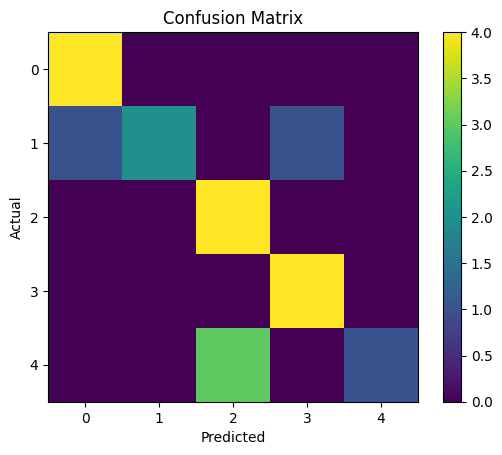

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()